# Synthetic Customer & Transaction Data — Method Comparison

Compares five synthesis strategies on the same seed data:

| # | Method | Synthesizer | Key property |
|---|---|---|---|
| 1 | **HMA + Gaussian Copula** | SDV default multi-table | Native FK integrity + cardinality |
| 2 | **Independent CTGAN** | CTGANSynthesizer per table | Better within-table distributions |
| 3 | **CTGAN + PAR Hybrid** | CTGAN (customers) + PAR (transactions) | Temporal realism + cross-table context |
| 4 | **Independent TVAE** | TVAESynthesizer per table | VAE: smooth marginals, stable training |
| 5 | **SmartNoise MST** | OpenDP MST (differentially private) | Formal (ε, δ)-DP privacy guarantee |

**Evaluation axes**
- Standard SDMetrics: Column Shapes, Column Pair Trends, Diagnostic
- **Cross-table correlation** (custom): Spearman(income → % investment products) — preserved?
- **Temporal realism** (custom): inter-arrival time KS test + amount autocorrelation

In [ ]:
import sys, warnings, logging, os
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)          # suppress JAX / SmartNoise / SDV logging warnings
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)  # silence all progress bars

DATA_DIR    = Path('data')
REPORTS_DIR = Path('reports')
DATA_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
METHOD_COLORS = {
    'M1 – HMA GC':    '#4e79a7',
    'M2 – CTGAN':     '#f28e2b',
    'M3 – CTGAN+PAR': '#59a14f',
    'M4 – TVAE':      '#e15759',
    'M5 – SmartNoise': '#b07aa1',
    'Real':           '#bab0ac',
}
print('Ready.')

---
## 1  Seed Data

500 customers with business-rule-driven demographics and transaction histories.  
This is the **real** dataset all three synthesizers learn from.

In [2]:
from src.seed_data import make_seed_data

real_data = make_seed_data(n_customers=2000, avg_txns=12)
for name, df in real_data.items():
    df.to_csv(DATA_DIR / f'real_{name}.csv', index=False)

real_2t = {k: real_data[k] for k in ('customers', 'transactions')}
df_c = real_data['customers']
df_t = real_data['transactions']

print(f'customers    : {len(df_c):,} rows')
print(f'transactions : {len(df_t):,} rows  (avg {len(df_t)/len(df_c):.1f} per customer)')
print(f'products     : {len(real_data["products"]):,} rows  (static catalog)')

customers    : 2,000 rows
transactions : 23,951 rows  (avg 12.0 per customer)
products     : 15 rows  (static catalog)


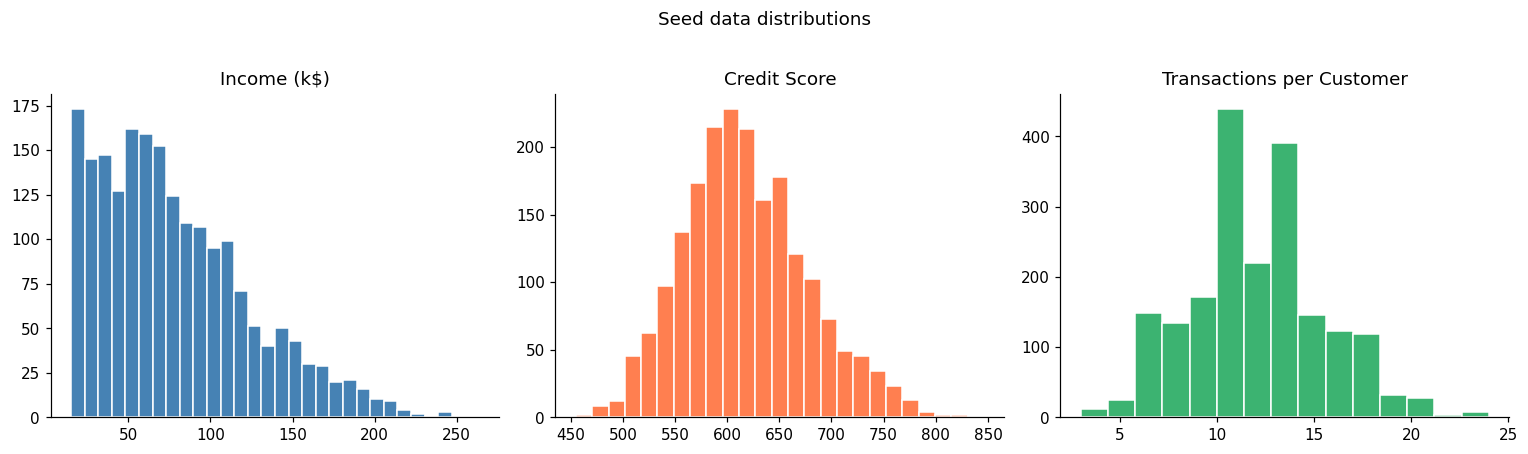

Pearson(income -> %investment): 0.625
Pearson(credit_score -> %investment): 0.444
Pearson(age -> %investment): -0.005


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_c['income'] / 1000, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Income (k$)')
axes[1].hist(df_c['credit_score'], bins=25, color='coral', edgecolor='white')
axes[1].set_title('Credit Score')
tc = df_t.groupby('customer_id').size()
axes[2].hist(tc, bins=15, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Transactions per Customer')

plt.suptitle('Seed data distributions', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'seed_overview.png', bbox_inches='tight')
plt.show()

# Key signal the synthesizers need to preserve
pct_inv = df_t.groupby('customer_id').apply(
    lambda g: (g['product_category'] == 'Investment').mean()
).rename('pct_investment')
merged = df_c.set_index('customer_id').join(pct_inv)
for feat in ['income', 'credit_score', 'age']:
    corr = merged[feat].corr(merged['pct_investment'])
    print(f'Pearson({feat} -> %investment): {corr:.3f}')

In [4]:
from src.metrics_extended import cross_table_correlation

real_ct = cross_table_correlation(df_c, df_t)
print('Real Spearman correlations (feature → % product category):')
real_ct.pivot(index='feature', columns='category', values='spearman_r').round(3)

Real Spearman correlations (feature → % product category):


category,Banking,Credit,Insurance,Investment
feature,,,,
age,-0.041,-0.062,0.149,-0.009
credit_score,-0.629,0.796,-0.246,0.546
income,-0.678,0.565,-0.170,0.764


---
## 2  Schema: Auto-detected vs Hand-crafted

SDV's `detect_from_dataframes()` infers column types and FK relationships automatically.
The cell below runs auto-detection on the real seed data and compares it column-by-column
against the hand-crafted schema in `src/schema.py`.

**What auto-detection gets right**
- Primary keys (`customer_id`, `transaction_id`, `product_id`)
- Most categorical columns (`gender`, `education`, `occupation`, `channel`, `status`, …)
- Numerical columns (`income`, `credit_score`, `amount`, `tenure_years`, …)
- Datetime format — correctly infers `transaction_date` as `datetime` with `"%Y-%m-%d"`
- FK relationships — infers both `customers → transactions` and `products → transactions`
  from matching ID column names

**What auto-detection gets wrong or misses**

| Column | Auto-detected | Hand-crafted | Why it matters |
|---|---|---|---|
| `products.is_premium` | `categorical` | `boolean` | Synthesised as strings `True`/`False`, not proper booleans |
| `customers.is_churned` | `categorical` | `boolean` | Boolean semantics lost; downstream type errors |
| `transactions.is_first_product` | `categorical` | `boolean` | Same |
| `customers.num_dependents` | `categorical` | `numerical (Int64)` | Treated as a label; loses integer ordering and range |
| Integer numerics (`age`, `credit_score`, `num_dependents`) | `numerical` (no repr) | `numerical + Int64` | Without `Int64`, SDV may generate floats like `42.7` for age |
| Float numerics (`income`, `amount`, `tenure_years`) | `numerical` (no repr) | `numerical + Float` | Explicit declaration prevents regressions if SDV changes defaults |
| All ID columns | `id` (no format) | `id + regex_format` | Without regex, synthesised IDs break `C[0-9]{5}` / `T[0-9]{6}` patterns |
| `transactions.product_id` | `id` (FK to products) | `categorical` (2-table schema) | Auto-detect enforces FK integrity to products; hand-crafted intentionally decouples it so product IDs are learned as a distribution |

In [5]:
import json
from sdv.metadata import MultiTableMetadata
from src.schema import build_metadata_2table, build_metadata

# ── Auto-detected schema ──────────────────────────────────────────────────────
auto_meta = MultiTableMetadata()
auto_meta.detect_from_dataframes(real_data)
auto_dict = auto_meta.to_dict()

with open(REPORTS_DIR / 'auto_detected_metadata.json', 'w') as f:
    json.dump(auto_dict, f, indent=2)

# Hand-crafted: use 2-table for customers/transactions, full 3-table for products
hand_2t   = build_metadata_2table().to_dict()
hand_full = build_metadata().to_dict()
hand_by_table = {
    'customers':    hand_2t['tables']['customers']['columns'],
    'transactions': hand_2t['tables']['transactions']['columns'],
    'products':     hand_full['tables']['products']['columns'],
}

# ── Render full sdtype string including all details ───────────────────────────
def fmt(col_props: dict) -> str:
    if not col_props:
        return '(not in schema)'
    parts = [col_props.get('sdtype', '?')]
    if col_props.get('computer_representation'):
        parts.append(col_props['computer_representation'])
    if col_props.get('regex_format'):
        parts.append(f'regex={col_props["regex_format"]}')
    if col_props.get('datetime_format'):
        parts.append(col_props['datetime_format'])
    return '  '.join(parts)

# ── Build comparison rows ─────────────────────────────────────────────────────
TABLE_NOTES = {
    'products': '(excluded from 2-table training schema — static lookup only)'
}

rows = []
for table in ('customers', 'transactions', 'products'):
    auto_cols = auto_dict['tables'].get(table, {}).get('columns', {})
    hand_cols = hand_by_table.get(table, {})
    for col in sorted(set(auto_cols) | set(hand_cols)):
        a      = auto_cols.get(col, {})
        h      = hand_cols.get(col, {})
        a_str  = fmt(a)
        h_str  = fmt(h)
        a_type = a.get('sdtype', '')
        h_type = h.get('sdtype', '')

        if a_str == h_str:
            status = '✓  exact'
        elif a_type == h_type:
            status = '~  partial'   # same sdtype, missing detail (repr / regex / format)
        else:
            status = '✗  mismatch'  # wrong sdtype entirely

        rows.append({
            'table':         table + (' *' if table == 'products' else ''),
            'column':        col,
            'auto_detected': a_str,
            'hand_crafted':  h_str,
            'status':        status,
        })

cmp_schema = pd.DataFrame(rows)

# ── Style: colour by status ───────────────────────────────────────────────────
STATUS_COLORS = {
    '✓  exact':    'background-color: #f0fdf4',   # green tint
    '~  partial':  'background-color: #fef9c3',   # yellow tint
    '✗  mismatch': 'background-color: #fee2e2',   # red tint
}

def _color_row(row):
    c = STATUS_COLORS.get(row['status'], '')
    return [c] * len(row)

display(
    cmp_schema.style
        .apply(_color_row, axis=1)
        .set_caption(
            'Schema comparison  |  ✓ exact match  ~  same sdtype, missing detail  ✗ wrong type\n'
            '* products excluded from 2-table training schema (static lookup)'
        )
        .set_properties(**{'font-size': '12px'})
        .hide(axis='index')
)

exact    = (cmp_schema['status'] == '✓  exact').sum()
partial  = (cmp_schema['status'] == '~  partial').sum()
mismatch = (cmp_schema['status'] == '✗  mismatch').sum()
print(f'✓ exact: {exact}   ~ partial (missing detail): {partial}   ✗ mismatch: {mismatch}')

table,column,auto_detected,hand_crafted,status
customers,age,numerical,numerical Int64,~ partial
customers,credit_score,numerical,numerical Int64,~ partial
customers,customer_id,id,id regex=C[0-9]{5},~ partial
customers,education,categorical,categorical,✓ exact
customers,gender,categorical,categorical,✓ exact
customers,income,numerical,numerical Float,~ partial
customers,is_churned,categorical,boolean,✗ mismatch
customers,marital_status,categorical,categorical,✓ exact
customers,num_dependents,categorical,numerical Int64,✗ mismatch
customers,occupation,categorical,categorical,✓ exact


✓ exact: 11   ~ partial (missing detail): 11   ✗ mismatch: 5


---
## 3  Method 1 — HMA + Gaussian Copula

SDV's default multi-table synthesizer. Trains Gaussian Copula on each table, then learns the
**extension model**: how many child rows each parent has and what their aggregate stats look like.
This preserves the transaction-count-per-customer distribution natively.

Schema: **2-table** (customers → transactions). `products` is a static lookup, not synthesized.

In [6]:
from src.methods import train_hma_gc, generate_hma_gc

t0 = time.time()
m1 = train_hma_gc(real_2t, save=True)
print(f'M1 train: {time.time()-t0:.1f}s')

t0 = time.time()
s1 = generate_hma_gc(m1, n_customers=2000, seed_size=2000)
print(f'M1 sample: {time.time()-t0:.1f}s | customers={len(s1["customers"]):,}  transactions={len(s1["transactions"]):,}')

s1['customers'].to_csv(DATA_DIR / 'm1_customers.csv', index=False)
s1['transactions'].to_csv(DATA_DIR / 'm1_transactions.csv', index=False)
orphans = s1['transactions'][~s1['transactions']['customer_id'].isin(s1['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}  (must be 0)')


Preprocess Tables:   0%|          | 0/2 [00:00<?, ?it/s]


Preprocess Tables:  50%|█████     | 1/2 [00:00<00:00,  5.97it/s]


Preprocess Tables: 100%|██████████| 2/2 [00:00<00:00,  3.34it/s]


Preprocess Tables: 100%|██████████| 2/2 [00:00<00:00,  3.57it/s]


Learning relationships:


...


Modeling Tables:   0%|          | 0/2 [00:00<?, ?it/s]


Modeling Tables:  50%|█████     | 1/2 [00:00<00:00,  2.32it/s]


Modeling Tables: 100%|██████████| 2/2 [00:00<00:00,  4.44it/s]

M1 train: 9.1s


M1 sample: 50.3s | customers=2,000  transactions=23,951
Orphan FK rows: 0  (must be 0)


---
## 4  Method 2 — Independent CTGAN

CTGANSynthesizer trained separately on each table.  
CTGAN uses **mode-specific normalisation** for numericals and a **conditional generator** for
categoricals, avoiding mode collapse — better marginal distributions than Gaussian Copula.

**Limitation:** transactions are sampled independently; cross-table correlations (income → product
category) are NOT captured at sampling time.  Cardinality is preserved by re-sampling transaction
counts from the real distribution.

In [7]:
from src.methods import train_ctgan, generate_ctgan

t0 = time.time()
m2 = train_ctgan(real_2t, epochs=300, save=True)
print(f'M2 train: {time.time()-t0:.1f}s')

t0 = time.time()
s2 = generate_ctgan(m2, real_transactions=df_t, n_customers=2000)
print(f'M2 sample: {time.time()-t0:.1f}s | customers={len(s2["customers"]):,}  transactions={len(s2["transactions"]):,}')

s2['customers'].to_csv(DATA_DIR / 'm2_customers.csv', index=False)
s2['transactions'].to_csv(DATA_DIR / 'm2_transactions.csv', index=False)
orphans = s2['transactions'][~s2['transactions']['customer_id'].isin(s2['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e025ca170>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e025ca170>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e025ca170>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e025ca170>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e025ca170>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e022ac280>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e022ac280>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e022ac280>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M2 train: 279.0s


M2 sample: 74.9s | customers=2,000  transactions=24,072
Orphan FK rows: 0


---
## 5  Method 3 — CTGAN + PAR Hybrid

- **CTGAN** for customers (same as M2).
- **PARSynthesizer** (RNN) for transactions, ordered by `transaction_date`.
  Customer features `income` and `credit_score` are passed as `context_columns` so PAR
  learns *"high-income customer → investment products in sequence"*.
- **FK join:** PAR generates sequences with its own sampled context. Each PAR sequence is
  matched to the nearest synthetic customer by `(income, credit_score)` via k-NN.

This is the only method that models temporal ordering explicitly.

In [8]:
from src.methods import train_hybrid, generate_hybrid

t0 = time.time()
m3 = train_hybrid(real_2t, ctgan_epochs=300, par_epochs=128, save=True)
print(f'M3 train: {time.time()-t0:.1f}s')

t0 = time.time()
s3 = generate_hybrid(m3, n_customers=2000)
print(f'M3 sample: {time.time()-t0:.1f}s | customers={len(s3["customers"]):,}  transactions={len(s3["transactions"]):,}')

s3['customers'].to_csv(DATA_DIR / 'm3_customers.csv', index=False)
s3['transactions'].to_csv(DATA_DIR / 'm3_transactions.csv', index=False)
orphans = s3['transactions'][~s3['transactions']['customer_id'].isin(s3['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e02071ea0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M3 train: 582.9s


M3 sample: 60.6s | customers=2,000  transactions=23,199
Orphan FK rows: 0


---
## 6  Method 4 — Independent TVAE

**TVAESynthesizer** trained separately on each table (like M2) — but a **variational autoencoder** instead of a GAN. TVAE typically yields smoother numeric marginals and trains more stably than CTGAN, at the cost of sometimes blurrier categorical boundaries.

Cardinality is re-sampled from the real distribution; cross-table correlations are **not** modelled at sampling time (same limitation as M2). All methods are fitted under SDV **CAG constraints** (`src/constraints.py`): `FixedCombinations` (product↔category) + `ScalarInequality` (amount ≥ 0) on transactions, and `FixedIncrements` (whole dependents) + `ScalarRange` (credit_score ∈ [300, 850]) + `Inequality` (tenure ≤ age) on customers. PAR (M3) can't take `FixedCombinations`, so it keeps a few product/category drifts.

In [9]:
from src.methods import train_tvae, generate_tvae

t0 = time.time()
m4 = train_tvae(real_2t, epochs=300, save=True)
print(f'M4 train: {time.time()-t0:.1f}s')

t0 = time.time()
s4 = generate_tvae(m4, real_transactions=df_t, n_customers=2000)
print(f'M4 sample: {time.time()-t0:.1f}s | customers={len(s4["customers"]):,}  transactions={len(s4["transactions"]):,}')

s4['customers'].to_csv(DATA_DIR / 'm4_customers.csv', index=False)
s4['transactions'].to_csv(DATA_DIR / 'm4_transactions.csv', index=False)
orphans = s4['transactions'][~s4['transactions']['customer_id'].isin(s4['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730f0e35e4d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730f0e35e4d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730f0e35e4d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730f0e35e4d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730f0e35e4d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e01ea52d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e01ea52d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x730e01ea52d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M4 train: 155.0s


M4 sample: 63.3s | customers=2,000  transactions=23,849
Orphan FK rows: 0


---
## 7  Method 5 — SmartNoise MST (differential privacy)

**SmartNoise** (OpenDP) synthesises each table under a formal **(ε, δ)-differential-privacy** guarantee — the one property no SDV method provides. **MST** is a marginal-based DP synthesizer: it spends the ε budget measuring noisy low-order marginals, then samples from a graphical model.

- Fit per table (like M2/M4); IDs dropped before fitting and regenerated after.
- `transaction_date` encoded as a day-offset; business rules restored by **post-processing** (clip to valid domains, map `product_id`→category) — DP synthesizers don't take SDV constraints, and post-processing a DP output preserves the guarantee.
- Budget: `epsilon` per table (≈ 2·ε total across the two tables).

In [ ]:
import contextlib, io
from src.smartnoise_method import train_smartnoise, generate_smartnoise

t0 = time.time()
with contextlib.redirect_stdout(io.StringIO()):   # suppress SmartNoise internal prints
    m5 = train_smartnoise(real_data, epsilon=3.0)
print(f'M5 train: {time.time()-t0:.1f}s  (ε=3.0 per table)')

t0 = time.time()
s5 = generate_smartnoise(m5, real_transactions=df_t, n_customers=2000)
print(f'M5 sample: {time.time()-t0:.1f}s | customers={len(s5["customers"]):,}  transactions={len(s5["transactions"]):,}')

s5['customers'].to_csv(DATA_DIR / 'm5_customers.csv', index=False)
s5['transactions'].to_csv(DATA_DIR / 'm5_transactions.csv', index=False)
orphans = s5['transactions'][~s5['transactions']['customer_id'].isin(s5['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

---
## 8  Evaluation — All Metrics

Runs SDMetrics quality/diagnostic reports + the two custom metrics across all four methods.

In [11]:
from src.metrics_extended import compare_methods

synthetic_datasets = {
    'M1 – HMA GC':    s1,
    'M2 – CTGAN':     s2,
    'M3 – CTGAN+PAR': s3,
    'M4 – TVAE':      s4,
    'M5 – SmartNoise': s5,
}

print('Running full comparison …')
cmp = compare_methods(real_2t, synthetic_datasets)
cmp.to_csv(REPORTS_DIR / 'method_comparison.csv')
cmp

Running full comparison …
  Evaluating: M1 – HMA GC …


  Evaluating: M2 – CTGAN …


  Evaluating: M3 – CTGAN+PAR …


  Evaluating: M4 – TVAE …


  Evaluating: M5 – SmartNoise …


,quality_score,diagnostic_score,cust_column_shapes,cust_pair_trends,txn_column_shapes,cross_table_mad,cross_table_max_err,ia_ks_pvalue,ia_ks_stat,autocorr_mae,syn_ia_mean
method,,,,,,,,,,,
M1 – HMA GC,0.8884,1.0000,0.9467,0.7365,0.8650,0.3787,0.8303,0.0000,0.0605,0.0788,93.52
M2 – CTGAN,0.8535,1.0000,0.8403,0.5667,0.9078,0.3935,0.8261,0.0416,0.0132,0.0114,113.11
M3 – CTGAN+PAR,0.6469,0.7439,0.7860,0.5474,0.7827,0.2961,0.8216,0.0000,0.3343,0.0413,50.42
M4 – TVAE,0.8867,1.0000,0.7946,0.7804,0.8261,0.3922,0.8077,0.0000,0.2504,0.0284,85.99
M5 – SmartNoise,0.8610,0.9997,0.9340,0.8495,0.8560,0.3874,0.7906,0.0000,0.9574,0.5685,7.64


---
### 8a  SDMetrics Quality Report — Visualizations

`QualityReport.get_visualization(property_name)` returns an interactive **Plotly** figure for each SDMetrics property:

| Property | Metric used | What 1.0 means |
|---|---|---|
| **Column Shapes** | KSComplement (numerical) / TVComplement (categorical) | Synthetic marginal = real marginal |
| **Column Pair Trends** | CorrelationSimilarity / ContingencySimilarity | Pairwise relationship perfectly reproduced |

One figure is rendered per method × property so you can drill into per-table, per-column fidelity.  
The overall scores printed here match the `quality_score` column in the `cmp` dataframe above.

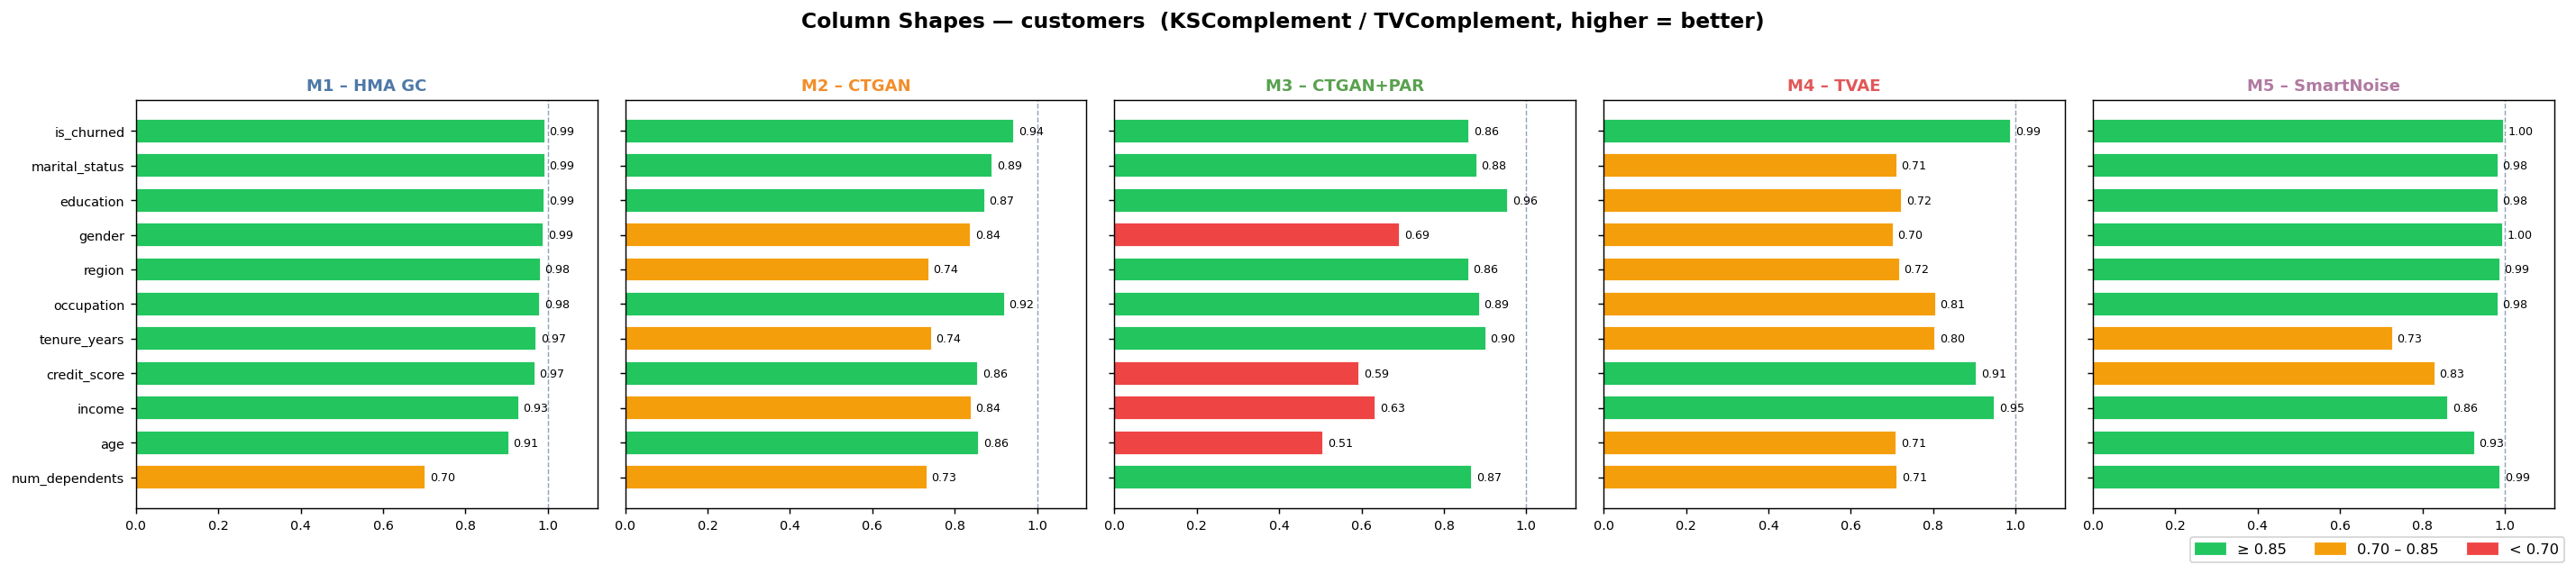

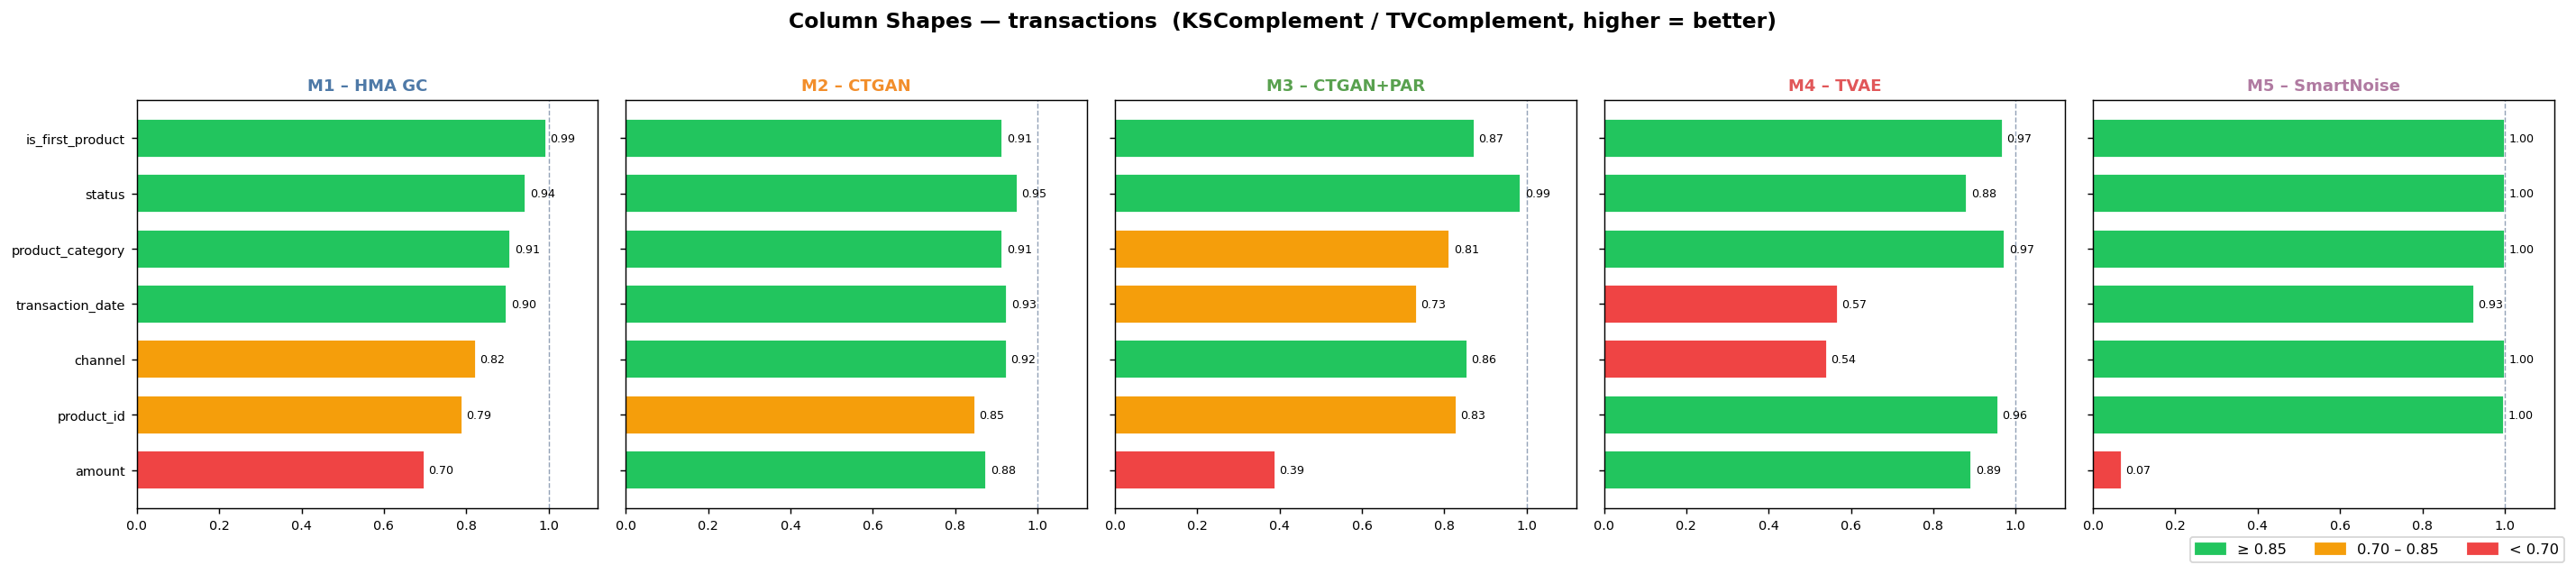

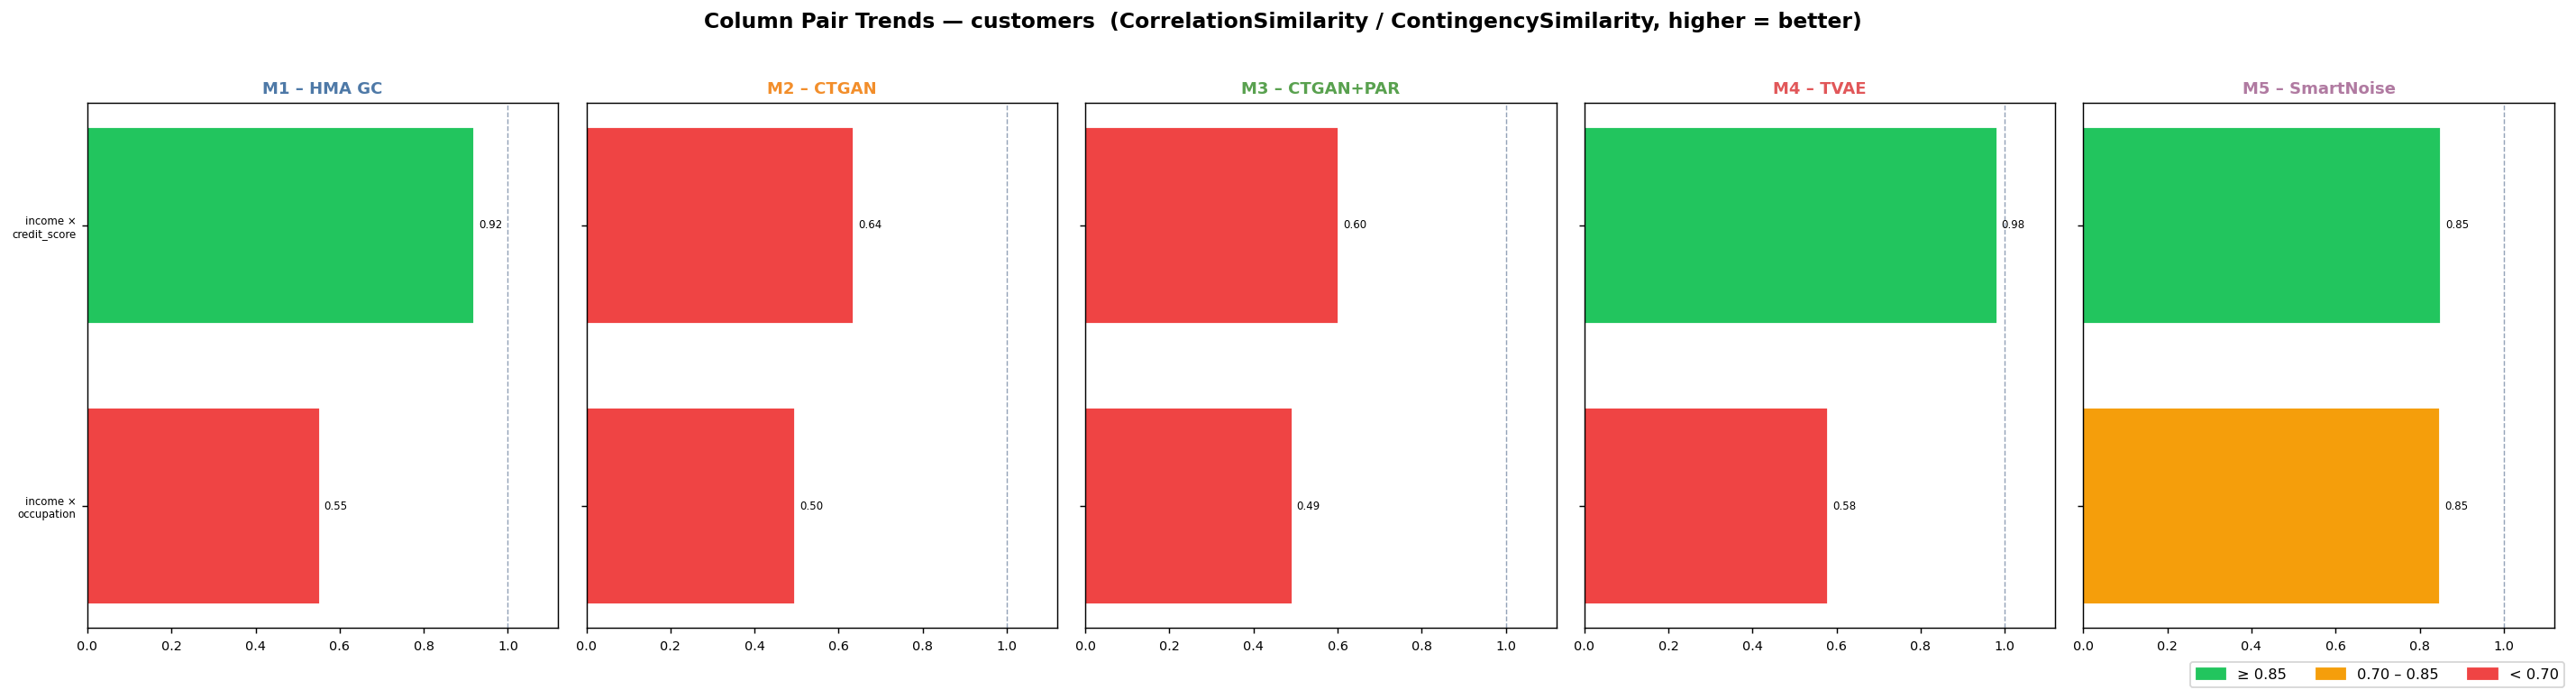

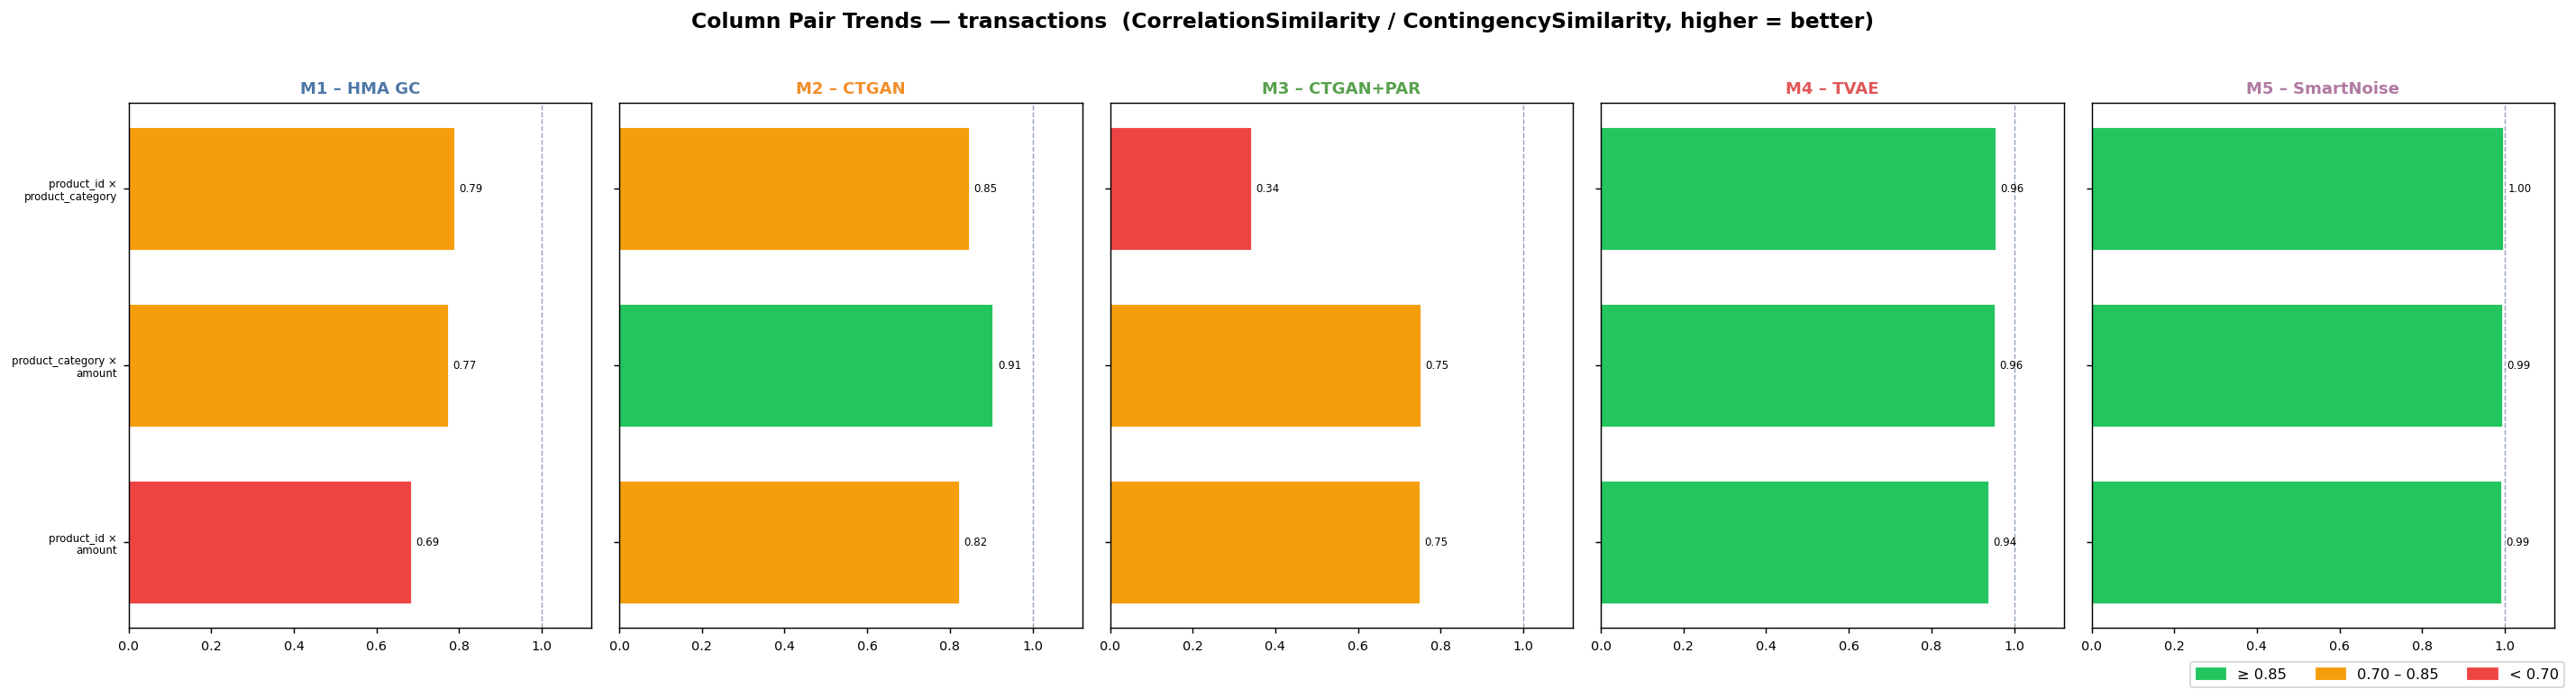

In [1]:
from sdmetrics.reports.multi_table import QualityReport
from src.schema import build_metadata_2table
import matplotlib, matplotlib.pyplot as plt, matplotlib.patches as mpatches

meta_2t = build_metadata_2table().to_dict()

# Run a fresh QualityReport for each method
print("Generating QualityReports ...")
qr_reports = {}
for name, syn in synthetic_datasets.items():
    qr = QualityReport()
    qr.generate(real_2t, syn, meta_2t, verbose=False)
    qr_reports[name] = qr
    print(f"  {name:<22}  overall = {qr.get_score():.4f}")

METHOD_COLORS_LOCAL = {
    "M1 – HMA GC":     "#4e79a7",
    "M2 – CTGAN":      "#f28e2b",
    "M3 – CTGAN+PAR":  "#59a14f",
    "M4 – TVAE":       "#e15759",
    "M5 – SmartNoise": "#b07aa1",
}

def _qr_bar_chart(qr_reports, property_name, table, figsize=(22, 4.5)):
    fig, axes = plt.subplots(1, len(qr_reports), figsize=figsize, sharey=True)
    fig.suptitle(f"{property_name} — {table}  (higher = better)",
                 fontsize=13, fontweight="bold", y=1.02)
    for ax, (name, qr) in zip(axes, qr_reports.items()):
        det = qr.get_details(property_name)
        tbl = det[det["Table"] == table].copy()
        if property_name == "Column Pair Trends":
            tbl["label"] = tbl["Column 1"] + " ×\n" + tbl["Column 2"]
        else:
            tbl["label"] = tbl["Column"]
        tbl = tbl.sort_values("Score")
        colors = ["#ef4444" if s < 0.7 else "#f59e0b" if s < 0.85 else "#22c55e"
                  for s in tbl["Score"]]
        ax.barh(tbl["label"], tbl["Score"], color=colors, edgecolor="white", height=0.7)
        ax.axvline(1.0, color="#94a3b8", lw=0.8, ls="--")
        ax.set_xlim(0, 1.12)
        ax.set_title(f'M{list(qr_reports).index(name)+1} – {name.split("– ")[1]}',
                     fontsize=10, fontweight="bold", color=METHOD_COLORS_LOCAL[name])
        ax.tick_params(axis="y", labelsize=7); ax.tick_params(axis="x", labelsize=8)
        for bar, score in zip(ax.patches, tbl["Score"]):
            ax.text(min(score + 0.01, 1.08), bar.get_y() + bar.get_height()/2,
                    f"{score:.2f}", va="center", fontsize=7)
    patches = [mpatches.Patch(color="#22c55e", label="≥ 0.85"),
               mpatches.Patch(color="#f59e0b", label="0.70–0.85"),
               mpatches.Patch(color="#ef4444", label="< 0.70")]
    fig.legend(handles=patches, loc="lower right", bbox_to_anchor=(1, -0.04), ncol=3, fontsize=9)
    plt.tight_layout()
    return fig

for table in ("customers", "transactions"):
    fig = _qr_bar_chart(qr_reports, "Column Shapes", table)
    fig.savefig(REPORTS_DIR / f"qr_column_shapes_{table}.png", bbox_inches="tight", dpi=130)
    plt.show()

for table in ("customers", "transactions"):
    fig = _qr_bar_chart(qr_reports, "Column Pair Trends", table, figsize=(22, 5.5))
    fig.savefig(REPORTS_DIR / f"qr_column_pair_trends_{table}.png", bbox_inches="tight", dpi=130)
    plt.show()

---
### Constraint adherence

Every method is fitted under the SDV CAG constraints in `src/constraints.py`. The table below confirms each rule holds in the generated data. **M3/PAR** is the one exception on `prod/cat drift` — `FixedCombinations` is incompatible with PAR's sequence model, so it keeps a few product/category mismatches while every other rule still holds.

In [12]:
def _constraint_report(name, s):
    cu, tr = s['customers'], s['transactions']
    return {
        'method':            name,
        'orphan_fk':         int((~tr['customer_id'].isin(cu['customer_id'])).sum()),
        'prod/cat drift':    int((tr.groupby('product_id')['product_category'].nunique() > 1).sum()),
        'deps whole':        bool((cu['num_dependents'] == cu['num_dependents'].round()).all()),
        'credit in [300,850]': bool(cu['credit_score'].between(300, 850).all()),
        'tenure <= age':     bool((cu['tenure_years'] <= cu['age']).all()),
        'amount >= 0':       bool((tr['amount'] >= 0).all()),
    }

adherence = pd.DataFrame(
    [_constraint_report(n, s) for n, s in synthetic_datasets.items()]
).set_index('method')
adherence

,orphan_fk,prod/cat drift,deps whole,"credit in [300,850]",tenure <= age,amount >= 0
method,,,,,,
M1 – HMA GC,0,0,True,True,True,True
M2 – CTGAN,0,0,True,True,True,True
M3 – CTGAN+PAR,0,15,True,True,True,True
M4 – TVAE,0,0,True,True,True,True
M5 – SmartNoise,0,0,True,True,True,True


---
## 9  Cross-Table Correlation — Detail

Spearman correlation between customer features (income, credit_score, age) and their
per-customer product-category mix (% Banking / Credit / Insurance / Investment).

The heatmaps show whether each method preserves the real correlation structure.  
**MAD (mean absolute difference)** is the scalar summary — lower = better.

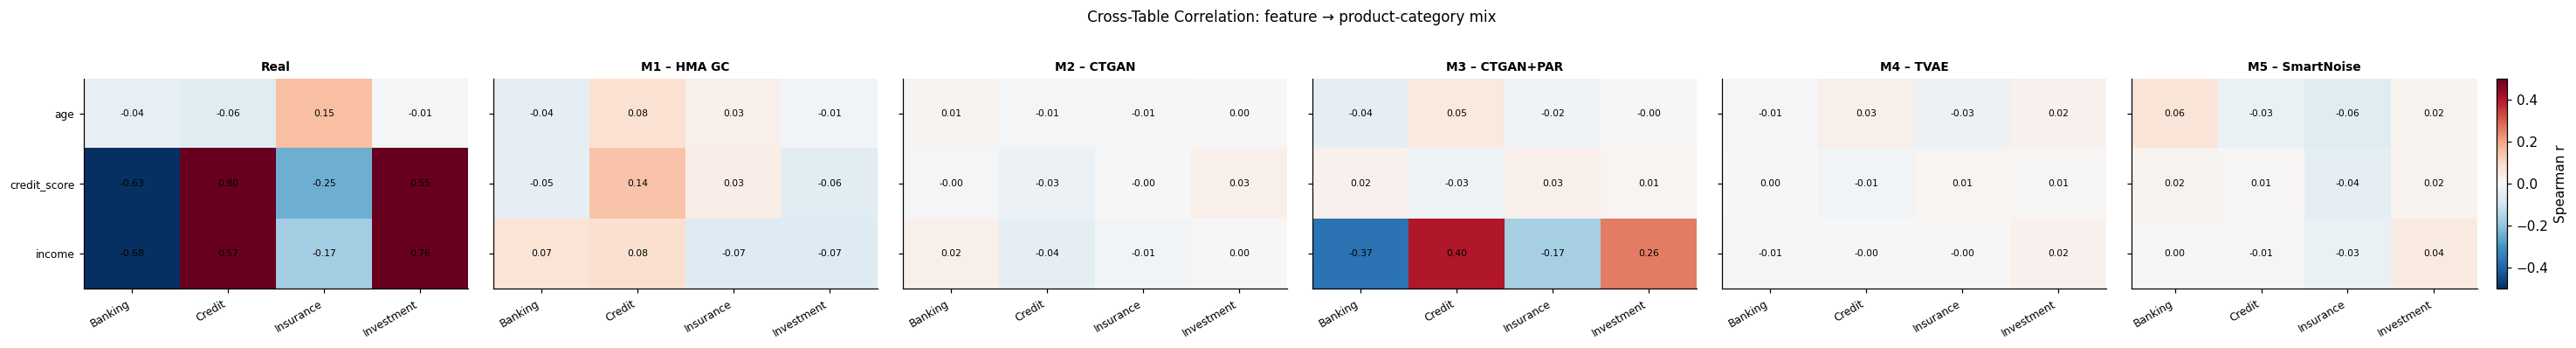

Cross-table MAD (lower = better):
  M1 – HMA GC           MAD=0.3787  max=0.8303
  M2 – CTGAN            MAD=0.3935  max=0.8261
  M3 – CTGAN+PAR        MAD=0.2961  max=0.8216
  M4 – TVAE             MAD=0.3922  max=0.8077
  M5 – SmartNoise       MAD=0.3874  max=0.7906


In [13]:
from src.metrics_extended import cross_table_score

n_panels = len(synthetic_datasets) + 1
fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 3.5), sharey=True)
all_sets = [('Real', df_c, df_t)] + [(n, s['customers'], s['transactions'])
                                      for n, s in synthetic_datasets.items()]

for ax, (name, cdf, tdf) in zip(axes, all_sets):
    corr  = cross_table_correlation(cdf, tdf)
    pivot = corr.pivot(index='feature', columns='category', values='spearman_r')
    im = ax.imshow(pivot.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)));  ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)));    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(name, fontweight='bold', fontsize=9)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=axes[-1], fraction=0.05, label='Spearman r')
fig.suptitle('Cross-Table Correlation: feature → product-category mix', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cross_table_heatmap.png', bbox_inches='tight')
plt.show()

print('Cross-table MAD (lower = better):')
for name, s in synthetic_datasets.items():
    sc = cross_table_score(df_c, df_t, s['customers'], s['transactions'])
    print(f'  {name:<20}  MAD={sc["mean_abs_delta"]:.4f}  max={sc["max_abs_delta"]:.4f}')

---
### Within-table correlation (customers)

Unlike the cross-table signal (feature → product category, which is weak for every method), the **within-customer** correlation structure — `income ↔ credit_score ↔ age ↔ tenure ↔ dependents` — is where the methods clearly differ. The heatmaps show each method's Pearson correlation matrix vs **Real**; the **MAE** (mean absolute error over the off-diagonal pairs, lower = better) scores how faithfully each reproduces that structure.

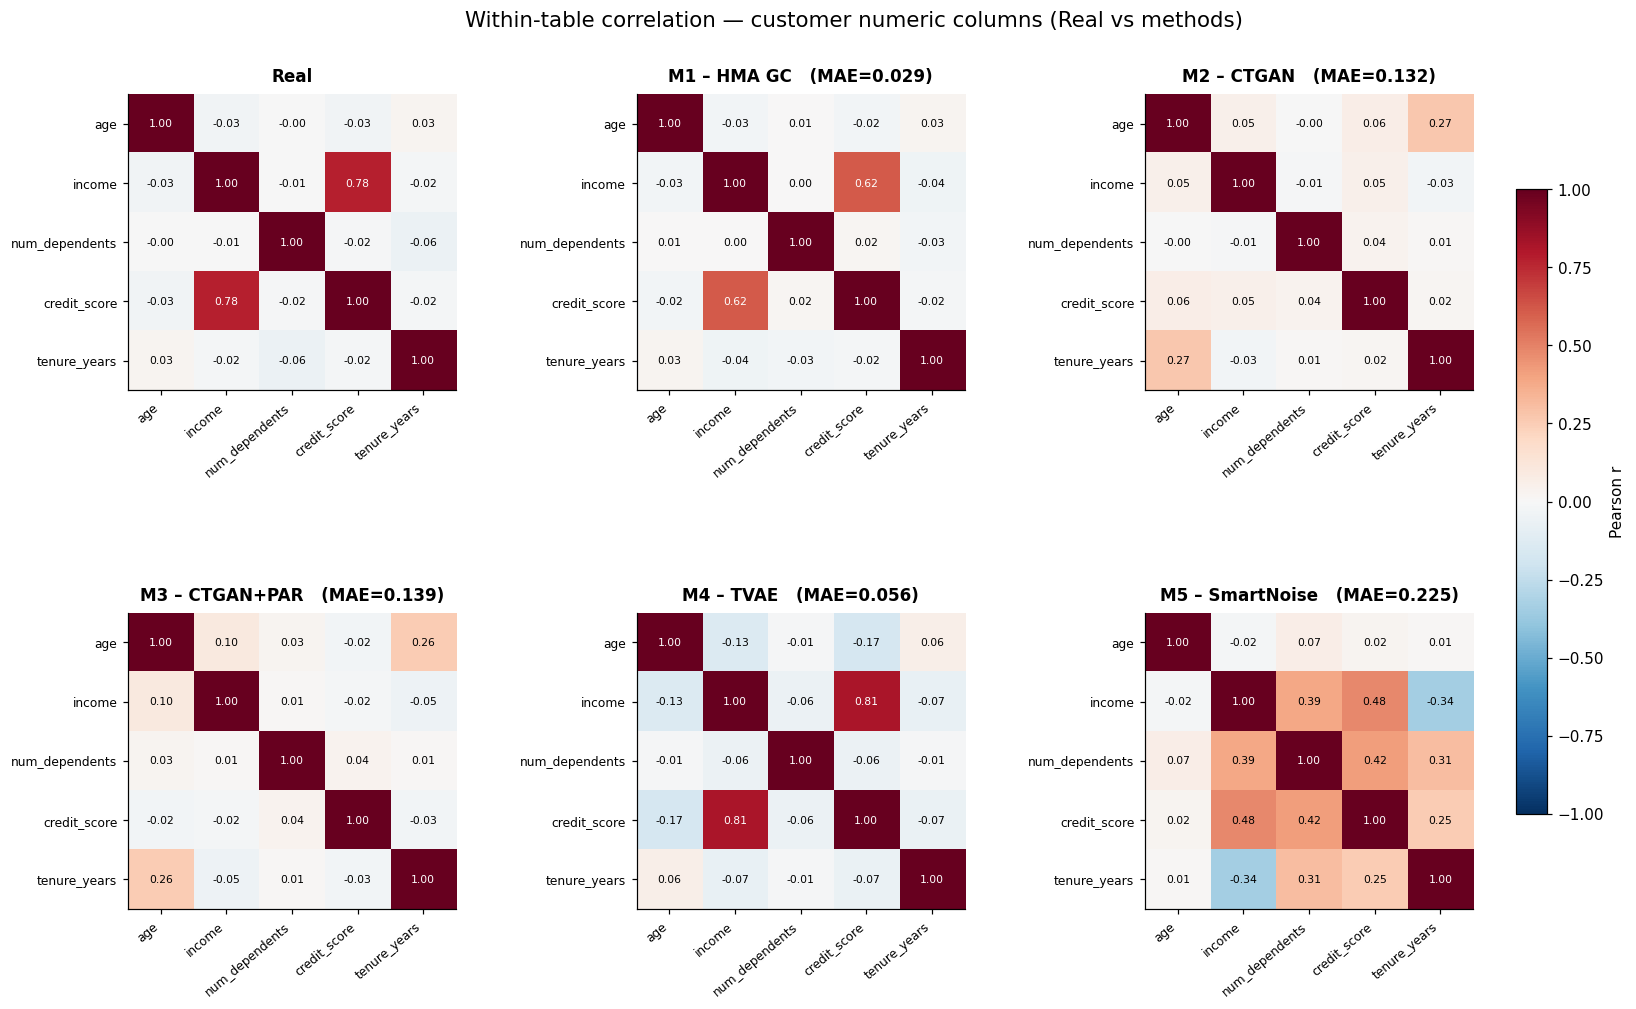

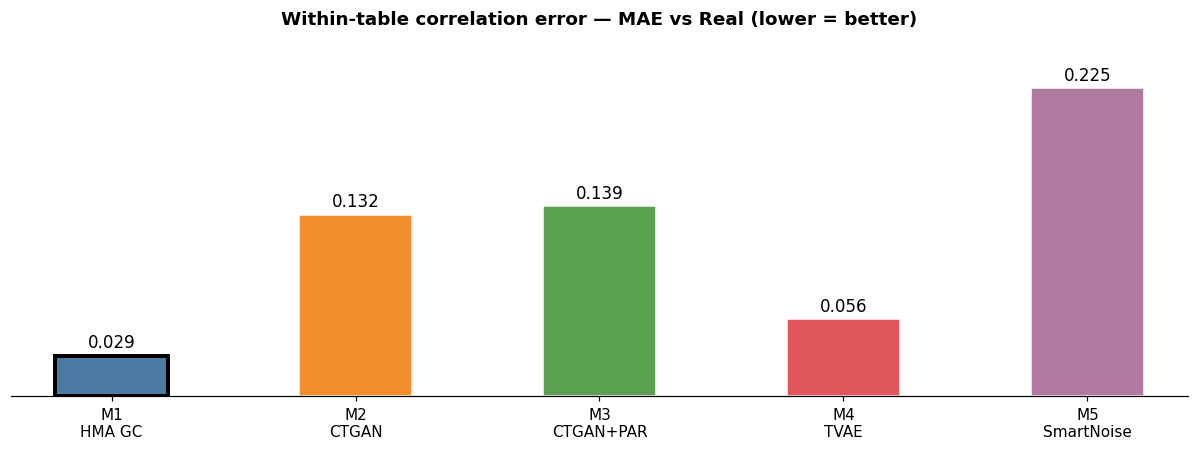

Within-table (customer) correlation MAE vs Real (lower = better):
  M1 – HMA GC        0.0292
  M2 – CTGAN         0.1324
  M3 – CTGAN+PAR     0.1386
  M4 – TVAE          0.0559
  M5 – SmartNoise    0.2247


In [14]:
# Within-table (customer) correlation structure — Real vs each method
from itertools import product as _prod
corr_cols = ['age', 'income', 'num_dependents', 'credit_score', 'tenure_years']
def _corr(dfc): return dfc[corr_cols].corr(method='pearson')

real_corr = _corr(df_c)
iu = np.triu_indices(len(corr_cols), 1)          # off-diagonal pairs only
panels = [('Real', df_c)] + [(n, s['customers']) for n, s in synthetic_datasets.items()]

# Figure 1 — correlation matrices (2 x 3), generous spacing so labels are readable
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5)); axes = axes.ravel()
for ax, (name, dfc) in zip(axes, panels):
    M = _corr(dfc).values
    im = ax.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    mae = np.abs(M - real_corr.values)[iu].mean()
    ax.set_title(name if name == 'Real' else f'{name}   (MAE={mae:.3f})',
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=8)
    for i, j in _prod(range(len(corr_cols)), repeat=2):
        ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(M[i,j]) > 0.55 else 'black')
for k in range(len(panels), len(axes)): axes[k].axis('off')
fig.subplots_adjust(wspace=0.55, hspace=0.75, left=0.06, right=0.92, top=0.9, bottom=0.12)
fig.colorbar(im, ax=axes, fraction=0.022, pad=0.03, label='Pearson r')
fig.suptitle('Within-table correlation — customer numeric columns (Real vs methods)', fontsize=14)
plt.savefig(REPORTS_DIR / 'in_table_correlation.png', bbox_inches='tight'); plt.show()

# Figure 2 — correlation-fidelity ranking (lower MAE = better), wide with spaced bars
maes = {n: float(np.abs(_corr(s['customers']).values - real_corr.values)[iu].mean())
        for n, s in synthetic_datasets.items()}
names = list(maes)
fig, ax = plt.subplots(figsize=(11, 4.2))
xpos = np.arange(len(names)) * 1.5          # extra gap between bars
bars = ax.bar(xpos, [maes[n] for n in names], width=0.7,
              color=[METHOD_COLORS[n] for n in names], edgecolor='white')
best_i = int(np.argmin([maes[n] for n in names]))
bars[best_i].set_edgecolor('black'); bars[best_i].set_linewidth(2.6)
ax.bar_label(bars, fmt='%.3f', fontsize=11, padding=3)
ax.set_xticks(xpos)
ax.set_xticklabels([f'M{i+1}\n{n.split(" – ")[1]}' for i, n in enumerate(names)], fontsize=10)
ax.set_title('Within-table correlation error — MAE vs Real (lower = better)', fontsize=12, fontweight='bold')
ax.set_yticks([]); ax.margins(x=0.04, y=0.18)
[ax.spines[s].set_visible(False) for s in ('top', 'right', 'left')]
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'in_table_corr_error.png', bbox_inches='tight'); plt.show()

print('Within-table (customer) correlation MAE vs Real (lower = better):')
for n in names: print(f'  {n:<18} {maes[n]:.4f}')

---
## 10  Temporal Realism — Detail

| Metric | How | Better |
|---|---|---|
| **Inter-arrival KS p-value** | KS test on days-between-consecutive-transactions | Higher |
| **Amount autocorr MAE** | |real_lag1_autocorr − syn_lag1_autocorr| | Lower |

Only PAR (M3) explicitly models the ordering of transactions within a customer's history.

Real: inter-arrival mean=110.7d  median=77.0d  autocorr=-0.0993


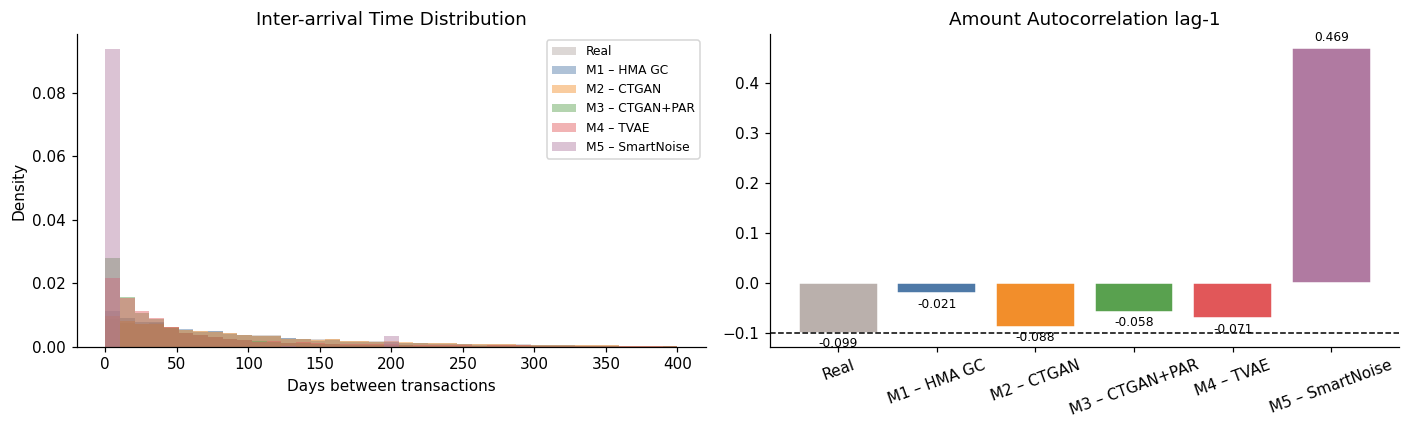


Temporal scores:


  M1 – HMA GC           KS p=0.0000  autocorr_MAE=0.0788  ia_mean=93.5d


  M2 – CTGAN            KS p=0.0416  autocorr_MAE=0.0114  ia_mean=113.1d


  M3 – CTGAN+PAR        KS p=0.0000  autocorr_MAE=0.0413  ia_mean=50.4d


  M4 – TVAE             KS p=0.0000  autocorr_MAE=0.0284  ia_mean=86.0d


  M5 – SmartNoise       KS p=0.0000  autocorr_MAE=0.5685  ia_mean=7.6d


In [15]:
from src.metrics_extended import temporal_stats, temporal_score

real_ts = temporal_stats(df_t)
print(f'Real: inter-arrival mean={real_ts["inter_arrival_mean"]:.1f}d  '
      f'median={real_ts["inter_arrival_median"]:.1f}d  '
      f'autocorr={real_ts["amount_autocorr_mean"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Inter-arrival histograms
bins = np.linspace(0, 400, 40)
axes[0].hist(real_ts['inter_arrival_values'], bins=bins, density=True,
             alpha=0.5, color=METHOD_COLORS['Real'], label='Real')
for name, s in synthetic_datasets.items():
    st = temporal_stats(s['transactions'])
    axes[0].hist(st['inter_arrival_values'], bins=bins, density=True,
                 alpha=0.45, color=METHOD_COLORS[name], label=name)
axes[0].set_xlabel('Days between transactions');  axes[0].set_ylabel('Density')
axes[0].set_title('Inter-arrival Time Distribution');  axes[0].legend(fontsize=8)

# Autocorrelation bar
names_bar  = ['Real'] + list(synthetic_datasets.keys())
ac_vals    = [real_ts['amount_autocorr_mean']] + [
    temporal_stats(s['transactions'])['amount_autocorr_mean']
    for s in synthetic_datasets.values()]
bars = axes[1].bar(names_bar, ac_vals, color=[METHOD_COLORS[n] for n in names_bar], edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
axes[1].axhline(real_ts['amount_autocorr_mean'], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Amount Autocorrelation lag-1')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'temporal_realism.png', bbox_inches='tight')
plt.show()

print('\nTemporal scores:')
for name, s in synthetic_datasets.items():
    ts = temporal_score(df_t, s['transactions'])
    print(f'  {name:<20}  KS p={ts["ia_ks_pvalue"]:.4f}  autocorr_MAE={ts["autocorr_mae"]:.4f}  ia_mean={ts["syn_ia_mean"]:.1f}d')

---
## 11  Comparison Dashboard

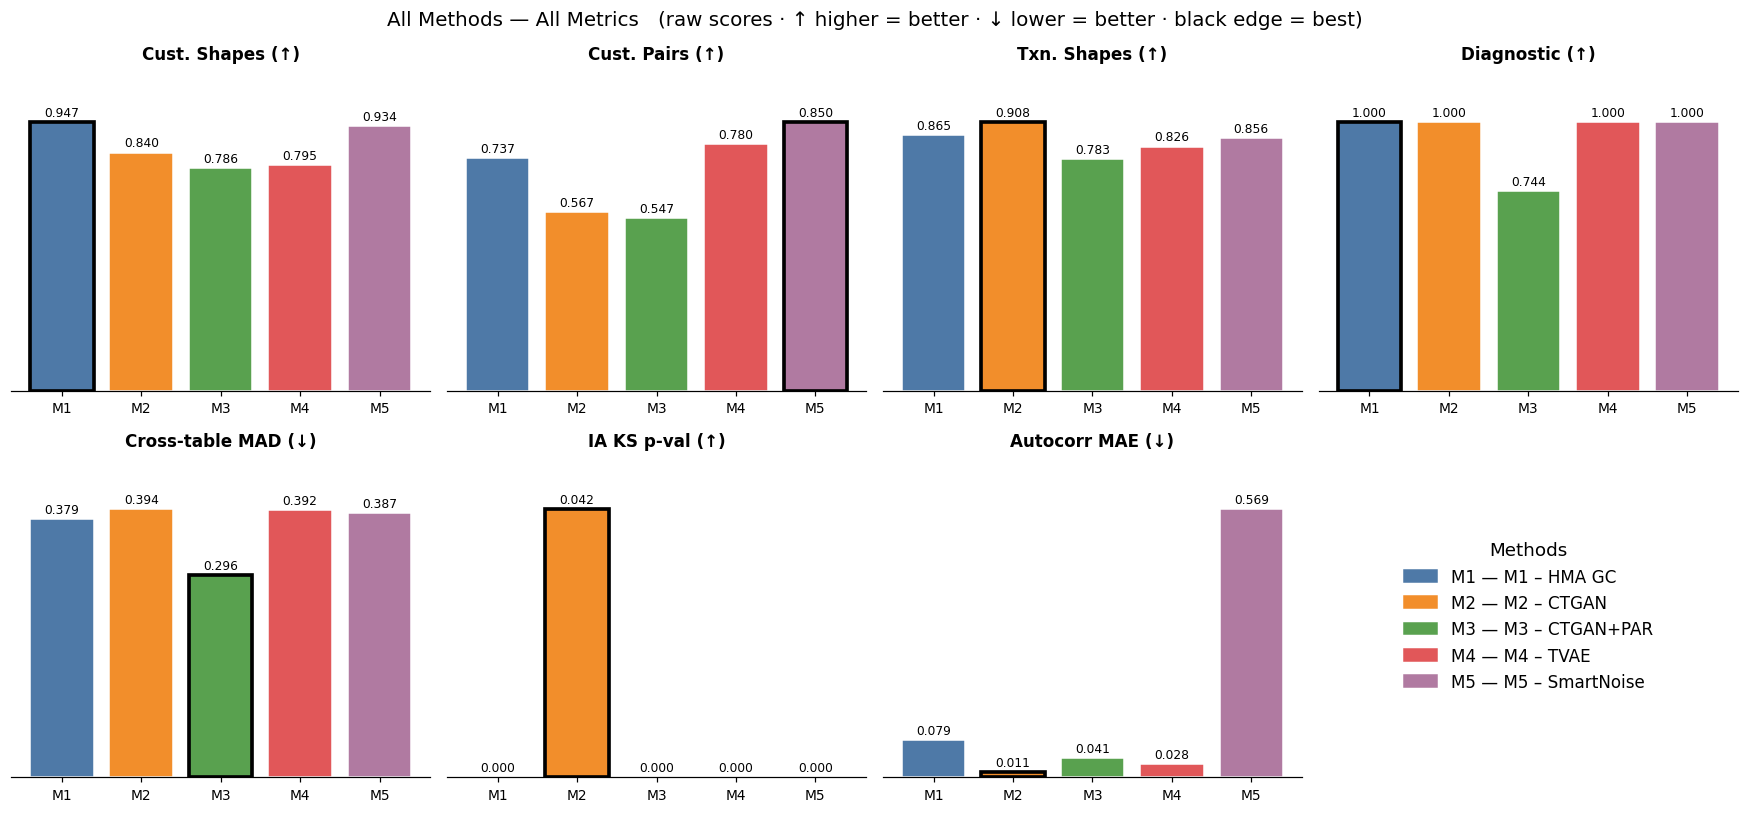

Metric                        M1        M2        M3        M4        M5   Best
-------------------------------------------------------------------------------
Cust. Shapes (↑)           0.947     0.840     0.786     0.795     0.934   M1
Cust. Pairs (↑)            0.737     0.567     0.547     0.780     0.850   M5
Txn. Shapes (↑)            0.865     0.908     0.783     0.826     0.856   M2
Diagnostic (↑)             1.000     1.000     0.744     1.000     1.000   M1
Cross-table MAD (↓)        0.379     0.394     0.296     0.392     0.387   M3
IA KS p-val (↑)            0.000     0.042     0.000     0.000     0.000   M2
Autocorr MAE (↓)           0.079     0.011     0.041     0.028     0.569   M2


In [16]:
metrics_cfg = {
    'Cust. Shapes (↑)':    ('cust_column_shapes', True),
    'Cust. Pairs (↑)':     ('cust_pair_trends',   True),
    'Txn. Shapes (↑)':     ('txn_column_shapes',  True),
    'Diagnostic (↑)':      ('diagnostic_score',   True),
    'Cross-table MAD (↓)': ('cross_table_mad',    False),
    'IA KS p-val (↑)':     ('ia_ks_pvalue',       True),
    'Autocorr MAE (↓)':    ('autocorr_mae',       False),
}
method_names = list(synthetic_datasets.keys())
short = {m: f'M{i+1}' for i, m in enumerate(method_names)}   # M1..M5 tick labels

# One small panel per metric — each keeps its own (raw) y-scale, so metrics are
# easy to read individually instead of being squashed onto one shared axis.
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
axes = axes.ravel()
for ax, (label, (col, higher)) in zip(axes, metrics_cfg.items()):
    if col not in cmp.columns:
        ax.axis('off'); continue
    vals  = [float(cmp.loc[m, col]) for m in method_names]
    best_i = int(np.argmax(vals)) if higher else int(np.argmin(vals))
    bars = ax.bar([short[m] for m in method_names], vals,
                  color=[METHOD_COLORS[m] for m in method_names], edgecolor='white')
    bars[best_i].set_edgecolor('black'); bars[best_i].set_linewidth(2.4)   # best = black edge
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.margins(y=0.20); ax.tick_params(axis='x', labelsize=9); ax.set_yticks([])
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)

# final panel = legend mapping M1..M5 → full method names
axes[-1].axis('off')
handles = [plt.Rectangle((0, 0), 1, 1, color=METHOD_COLORS[m]) for m in method_names]
axes[-1].legend(handles, [f'{short[m]} — {m}' for m in method_names], loc='center',
                fontsize=11, frameon=False, title='Methods', title_fontsize=12)

fig.suptitle('All Methods — All Metrics   (raw scores · ↑ higher = better · ↓ lower = better · black edge = best)',
             fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'comparison_dashboard.png', bbox_inches='tight')
plt.show()

header = f'{"Metric":<22}  ' + '  '.join(f'{short[m]:>8}' for m in method_names) + '   Best'
print('=' * len(header)); print(header); print('-' * len(header))
for label, (col, higher) in metrics_cfg.items():
    if col not in cmp.columns: continue
    vals = [float(cmp.loc[m, col]) for m in method_names]
    best = short[method_names[vals.index(max(vals) if higher else min(vals))]]
    print(f'{label:<22}  ' + '  '.join(f'{v:>8.3f}' for v in vals) + f'   {best}')
print('=' * len(header))

---
## Privacy (measured)

The SDV methods provide **no** privacy guarantee; **M5 (SmartNoise)** provides a formal (ε≈6, δ)-**differential-privacy** guarantee. Beyond that *guarantee*, we also **measure** empirical privacy on the (PII-bearing) customers table with SDMetrics:

- **NewRowSynthesis** — fraction of synthetic rows that aren't verbatim copies of a real row (higher = better).
- **DCRBaselineProtection** — synthetic→real distance-to-closest-record vs a random baseline; low values flag memorisation (higher = better).

**Key nuance:** a *formal DP guarantee* (M5) is not the same as the *best empirical DCR score*. DP bounds any single person's worst-case influence; DCR measures average closeness to real records. Because MST reproduces the marginals so faithfully, its rows sit **closest** to real data → **lowest** DCR protection, even though the DP guarantee still holds. Fidelity and closeness trade off.

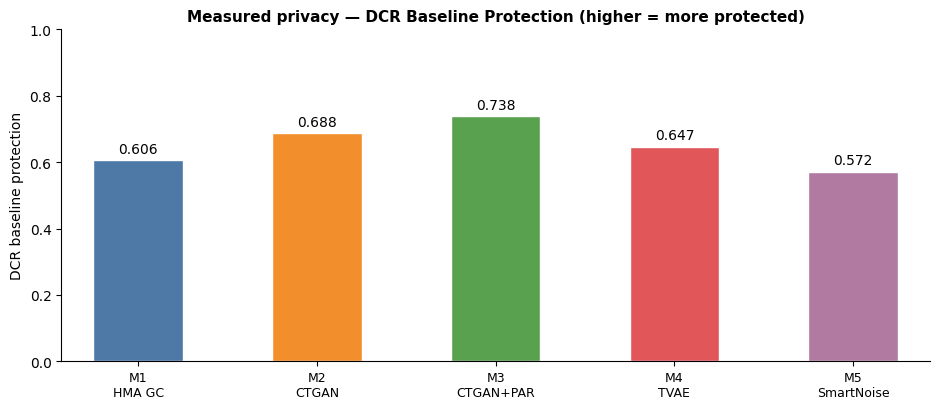

                 new_row_synthesis  dcr_protection
method                                            
M1 – HMA GC                    1.0          0.6056
M2 – CTGAN                     1.0          0.6880
M3 – CTGAN+PAR                 1.0          0.7384
M4 – TVAE                      1.0          0.6468
M5 – SmartNoise                1.0          0.5715
\nNote: NewRowSynthesis = 1.0 for all (continuous columns make verbatim copies near-impossible);
DCR protection discriminates — M5 (DP, best marginal fit) is closest to real, so lowest DCR.

In [ ]:
from src.metrics_extended import compare_privacy

priv = compare_privacy(real_2t, synthetic_datasets)
priv.to_csv(REPORTS_DIR / 'privacy_comparison.csv')

names = list(priv.index)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
xpos = np.arange(len(names)) * 1.4
bars = ax.bar(xpos, priv['dcr_protection'].values, width=0.7,
              color=[METHOD_COLORS[n] for n in names], edgecolor='white')
ax.bar_label(bars, fmt='%.3f', fontsize=10, padding=3)
ax.set_xticks(xpos); ax.set_xticklabels([f'M{i+1}\n{n.split(" – ")[1]}' for i, n in enumerate(names)], fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel('DCR baseline protection')
ax.set_title('Measured privacy — DCR Baseline Protection (higher = more protected)',
             fontsize=11, fontweight='bold')
ax.margins(x=0.04); [ax.spines[s].set_visible(False) for s in ('top', 'right')]
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'privacy_dcr.png', bbox_inches='tight'); plt.show()

print(priv.round(4).to_string())
print('\\nNote: NewRowSynthesis = 1.0 for all (continuous columns make verbatim copies near-impossible);')
print('DCR protection discriminates — M5 (DP, best marginal fit) is closest to real, so lowest DCR.')

---
### Measurable privacy — membership-inference audit (a "DP score")

ε itself is **accounted, not measured** — it is a worst-case property of the *algorithm*. What we **can** measure is empirical leakage: *can an attacker tell whether a record was in the training set?*

**Audit.** Members = the real training customers; non-members = a fresh draw from the **same** generative process (never seen by any synthesizer). For each record we take the distance to its nearest **synthetic** row. If a method memorises, members sit closer → the attacker (score = −distance) separates them → **AUC > 0.5**. We **bootstrap the AUC (B=300)** for 95% CIs, and report a **Clopper-Pearson empirical ε** lower bound.

> **Quick read:** every AUC interval straddles 0.50 and empirical ε = 0 → *no certifiable membership leakage* at this scale. M5 alone carries a **formal** ε≈6 guarantee that also bounds worst-case / outlier records and holds at any n.

  Audit: M1 – HMA GC …
  Audit: M2 – CTGAN …
  Audit: M3 – CTGAN+PAR …
  Audit: M4 – TVAE …
  Audit: M5 – SmartNoise …
  Audit bootstrap: M1 – HMA GC …
  Audit bootstrap: M2 – CTGAN …
  Audit bootstrap: M3 – CTGAN+PAR …
  Audit bootstrap: M4 – TVAE …
  Audit bootstrap: M5 – SmartNoise …
                 mia_auc  mia_advantage  eps_lower  member_dcr  nonmember_dcr
method                                                                       
M1 – HMA GC       0.4964        -0.0073        0.0      1.6070         1.6076
M2 – CTGAN        0.5017         0.0034        0.0      1.7284         1.7329
M3 – CTGAN+PAR    0.5101         0.0203        0.0      1.8303         1.8453
M4 – TVAE         0.5047         0.0093        0.0      1.7181         1.7409
M5 – SmartNoise   0.4946        -0.0107        0.0      1.8922         1.8792

All AUC ≈ 0.50 (CIs straddle 0.5) and empirical ε = 0 -> no certifiable membership leakage at n=2000 training customers.
M5 alone carries a FORMAL (ε≈6, δ)-DP guaran

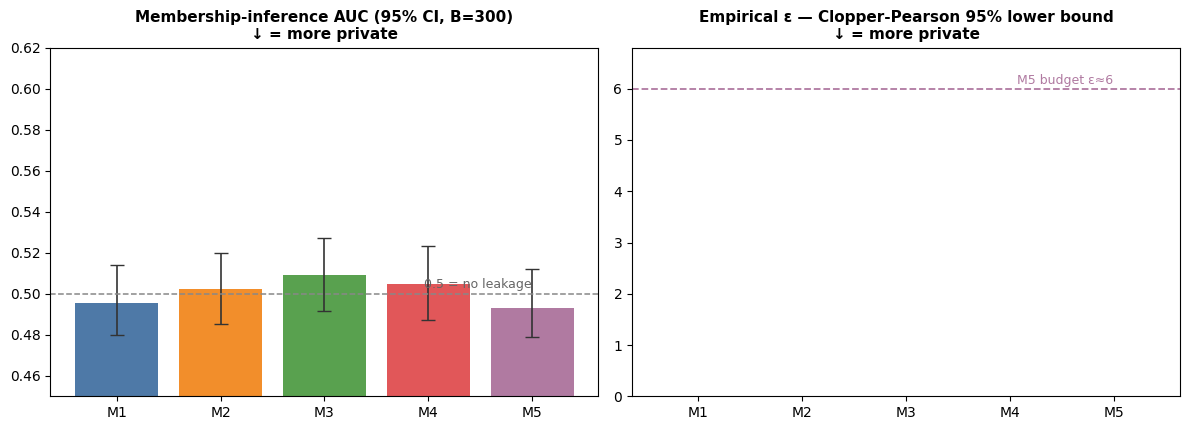

In [ ]:
from src.seed_data import make_seed_data
from src.metrics_extended import compare_privacy_audit, bootstrap_privacy_audit
import random

real_customers = real_2t['customers']
# fresh, disjoint non-member control drawn from the SAME generative process
random.seed(2024); np.random.seed(2024)
nonmembers = make_seed_data(n_customers=len(real_customers))['customers']

audit = compare_privacy_audit(real_customers, nonmembers, synthetic_datasets)
audit.to_csv(REPORTS_DIR / 'privacy_audit.csv')
boot  = bootstrap_privacy_audit(real_customers, nonmembers, synthetic_datasets, n_boot=300, seed=0)
asum  = boot['summary'].reindex(audit.index)

names  = list(audit.index)
colors = [METHOD_COLORS[n] for n in names]
med = asum['mia_auc_median'].values
err = np.vstack([med - asum['mia_auc_ci_low'].values, asum['mia_auc_ci_high'].values - med])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
a1.bar(range(len(names)), med, yerr=err, capsize=5, color=colors,
       error_kw=dict(ecolor='#333', lw=1.2))
a1.axhline(0.5, ls='--', color='#888', lw=1.1)
a1.text(len(names)-1, 0.503, '0.5 = no leakage', ha='right', fontsize=9, color='#666')
a1.set_ylim(0.45, 0.62); a1.set_xticks(range(len(names)))
a1.set_xticklabels([f'M{i+1}' for i in range(len(names))])
a1.set_title('Membership-inference AUC (95% CI, B=300)\n↓ = more private', fontsize=11, fontweight='bold')

a2.bar(range(len(names)), audit['eps_lower'].values, color=colors)
a2.axhline(6.0, ls='--', color='#b07aa1', lw=1.3)
a2.text(len(names)-1, 6.1, 'M5 budget ε≈6', ha='right', color='#b07aa1', fontsize=9)
a2.set_ylim(0, 6.8); a2.set_xticks(range(len(names)))
a2.set_xticklabels([f'M{i+1}' for i in range(len(names))])
a2.set_title('Empirical ε — Clopper-Pearson 95% lower bound\n↓ = more private', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'privacy_audit.png', bbox_inches='tight'); plt.show()

print(audit.round(4).to_string())
print(f"\nAll AUC ≈ 0.50 (CIs straddle 0.5) and empirical ε = 0 -> no certifiable membership "
      f"leakage at n={len(real_customers)} training customers.")
print("M5 alone carries a FORMAL (ε≈6, δ)-DP guarantee bounding worst-case/outlier records at any scale.")

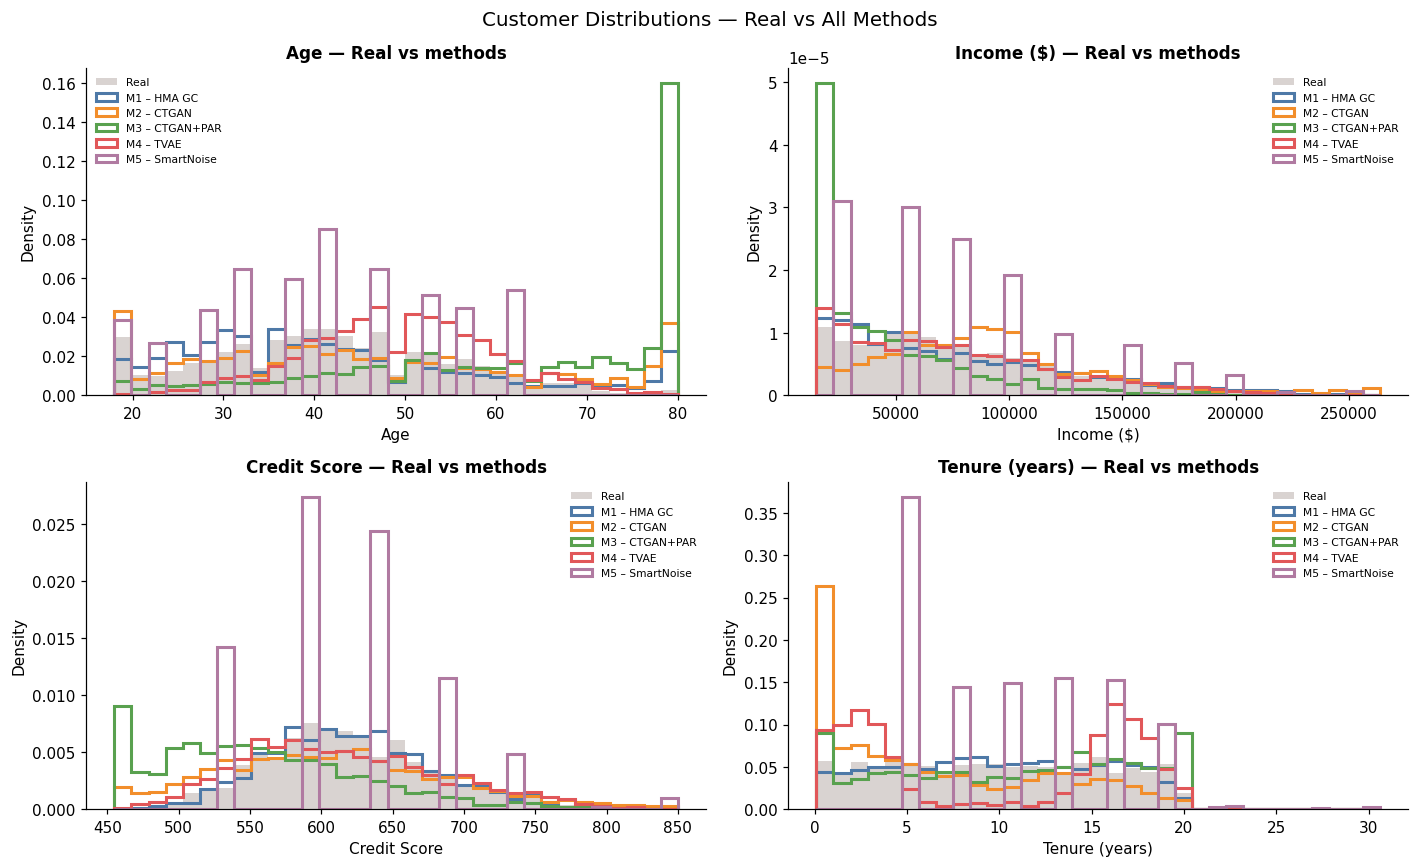

In [17]:
# Per-variable customer distributions — Real (grey fill) vs each method (step outline)
# Separate panels are easier to read/compare than one overlaid strip.
num_cols = [('age', 'Age'), ('income', 'Income ($)'),
            ('credit_score', 'Credit Score'), ('tenure_years', 'Tenure (years)')]
fname = {'age': 'dist_age', 'income': 'dist_income',
         'credit_score': 'dist_credit', 'tenure_years': 'dist_tenure'}

def _plot_dist(ax, col, label, title_size=11, legend_size=7):
    r = df_c[col].dropna()
    all_v = pd.concat([r] + [s['customers'][col].dropna() for s in synthetic_datasets.values()])
    bins = np.linspace(all_v.min(), all_v.max(), 34)
    ax.hist(r, bins=bins, density=True, color=METHOD_COLORS['Real'],
            alpha=0.55, label='Real', edgecolor='none')
    for name, s in synthetic_datasets.items():
        ax.hist(s['customers'][col].dropna(), bins=bins, density=True,
                histtype='step', color=METHOD_COLORS[name], linewidth=2.0, label=name)
    ax.set_title(f'{label} — Real vs methods', fontweight='bold', fontsize=title_size)
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.legend(fontsize=legend_size, frameon=False)

# 2x2 grid for the notebook
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, label) in zip(axes.ravel(), num_cols):
    _plot_dist(ax, col, label)
fig.suptitle('Customer Distributions — Real vs All Methods', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distributions_all_methods.png', bbox_inches='tight')
plt.show()

# Also save each variable as its own chart (used by the slide deck)
for col, label in num_cols:
    f1, a1 = plt.subplots(figsize=(6.4, 3.7))
    _plot_dist(a1, col, label, title_size=12, legend_size=8)
    f1.tight_layout()
    f1.savefig(REPORTS_DIR / f'{fname[col]}.png', bbox_inches='tight')
    plt.close(f1)

---
## 12  LLM Product Suggestions

Uses the best-performing synthetic dataset to power **DeepSeek** (`deepseek-chat`, OpenAI-compatible) product recommendations. The full product catalog goes in the system prompt and each call adds only the per-customer profile.

> **Requires `DEEPSEEK_API_KEY`** (read from the project `.env`) — cells auto-skip if not set.

In [18]:
import os
from src.llm_suggest import load_env
load_env()  # read DEEPSEEK_API_KEY from project .env

SKIP_LLM = not bool(os.environ.get('DEEPSEEK_API_KEY'))
if SKIP_LLM:
    print('DEEPSEEK_API_KEY not set — LLM cells skipped.')
    print('Add it to .env:  DEEPSEEK_API_KEY=sk-...')
else:
    print('DeepSeek API key found.')
    # Use M1 (HMA + Gaussian Copula) — the recommended method (best customer pair trends)
    best_method = next(m for m in synthetic_datasets if m.startswith('M1'))
    best_s = synthetic_datasets[best_method]
    print(f'Using {best_method} (recommended — customer pair trends={cmp.loc[best_method,"cust_pair_trends"]:.4f})')

DeepSeek API key found.
Using M1 – HMA GC (recommended — customer pair trends=0.7365)


In [19]:
if not SKIP_LLM:
    from src.llm_suggest import suggest
    sample_id = best_s['customers'].iloc[0]['customer_id']
    print(best_s['customers'][best_s['customers']['customer_id']==sample_id][
        ['age','gender','income','occupation','credit_score']].to_string(index=False))
    result = suggest(sample_id, best_s['customers'], best_s['transactions'])
    print(f'\nRecommendations for {sample_id}:')
    for i, rec in enumerate(result['recommendations'], 1):
        print(f'  {i}. [{rec["product_id"]}] {rec["name"]}')
        print(f'     {rec["reason"]}')
    tok = result['cache_tokens']
    print(f'\nTokens — input:{tok["input"]}  cache_create:{tok["cache_creation"]}  cache_read:{tok["cache_read"]}')

 age gender   income occupation  credit_score
  39   Male 134723.7    Retired           699



Recommendations for C01502:
  1. [P006] Credit Card Basic
     You have a solid credit score and high income, and you don't currently hold any credit card. A basic credit card can help you build credit history and manage everyday expenses conveniently.
  2. [P011] Investment Fund A
     With your high income and long tenure, a medium-risk investment fund is a suitable way to diversify your portfolio. It has a low entry point and balances potential growth with manageable risk.
  3. [P009] Health Insurance Basic
     You already hold a premium health insurance (P010), but having a basic plan as a secondary option can provide coverage for different scenarios or dependents at a lower cost.

Tokens — input:882  cache_create:0  cache_read:512


In [20]:
if not SKIP_LLM:
    from src.llm_suggest import batch_suggest
    ids   = best_s['customers'].sample(5, random_state=7)['customer_id'].tolist()
    batch = batch_suggest(ids, best_s['customers'], best_s['transactions'])
    rows  = [{'customer_id': r['customer_id'], 'rank': rk+1,
               'product_id': rec['product_id'], 'name': rec['name'],
               'cache_read': r['cache_tokens']['cache_read']}
             for r in batch if 'error' not in r
             for rk, rec in enumerate(r['recommendations'])]
    recs_df = pd.DataFrame(rows)
    recs_df.to_csv(REPORTS_DIR / 'llm_recommendations.csv', index=False)
    print(recs_df[recs_df['rank']==1][['customer_id','product_id','name','cache_read']].to_string(index=False))

customer_id product_id                  name  cache_read
     C00954       P007   Credit Card Premium         512
     C01058       P001 Basic Savings Account         512
     C00218       P013      Fixed Deposit 1Y         512
     C01023       P006     Credit Card Basic         512
     C00445       P006     Credit Card Basic         512


---
## 13  Findings & Recommendation

### Results at **2 000 seeds · ~12 transactions/customer** (SDV M1–M4 constraint-fitted · M5 SmartNoise ε≈6 DP)

| Metric | M1 HMA | M2 CTGAN | M3 PAR | M4 TVAE | M5 SmartNoise | Winner |
|---|---|---|---|---|---|---|
| Overall quality | **0.888** | 0.854 | 0.647 | 0.887 | 0.861 | M1 ≈ M4 |
| Diagnostic / FK | **1.000** | **1.000** | 0.744 | **1.000** | **1.000** | tie |
| Cust. column shapes | **0.947** | 0.840 | 0.786 | 0.795 | 0.934 | M1 |
| Cust. pair trends | 0.737 | 0.567 | 0.547 | 0.780 | **0.850** | M5 |
| Txn. column shapes | 0.865 | **0.908** | 0.783 | 0.826 | 0.856 | M2 |
| Within-table corr MAE ↓ | **0.029** | 0.132 | 0.139 | 0.056 | 0.225 | M1 |
| Cross-table MAD ↓ | 0.379 | 0.394 | **0.296** | 0.392 | 0.387 | M3 |
| IA KS p-value ↑ | 0.000 | **0.042** | 0.000 | 0.000 | 0.000 | M2 |
| Autocorr MAE ↓ | 0.079 | **0.011** | 0.041 | 0.028 | 0.569 | M2 |
| Diff. privacy guarantee | ✗ | ✗ | ✗ | ✗ | **✓ (ε≈6)** | M5 |
| DCR protection (measured) ↑ | 0.61 | 0.69 | **0.74** | 0.65 | 0.57 | M3 |

All methods: 0 orphan FKs, every business rule satisfied (only M3/PAR shows product/category drift).

---

### What changed when we scaled 1 000 → 2 000 customers & 4 → 12 txns/customer

**More data closed M5's quality lead.** At 1 000 seeds SmartNoise topped overall quality; at 2 000 the
neural methods caught up and **M1 (0.888) ≈ M4 (0.887)** edge it out. More rows help GAN/VAE/Copula
fitting more than they help the (already marginal-optimal) DP method.

**More transactions exposed the temporal gap.** With ~12 txns/customer the timing signal is finally
learnable — and **M5's autocorrelation collapses (MAE 0.569)** because MST models transactions as
independent rows with no sequence. M2 (CTGAN) is best on both temporal metrics.

**M5 is now the pair-trends leader (0.850)** on SDMetrics' mixed num+cat pairwise similarity, yet
**worst on the raw numeric correlation matrix (within-table MAE 0.225)** — its marginals and
categorical joints are excellent, but linear correlations among numerics are not. M1 owns raw
correlation (0.029).

---

### Privacy: guarantee ≠ measured protection

M5 is the **only** method with a formal **(ε≈6, δ)-DP guarantee**. But on the **measured** DCR metric it
is the **least** protected (0.57) and the worst-fidelity method (M3) is the **most** protected (0.74).
Reason: DP bounds any individual's worst-case influence; DCR measures average closeness to real
records. MST's faithful marginals place its rows nearest real data → lowest DCR. **Fidelity and
record-distance trade off**, and a DP guarantee does not imply the best empirical DCR. (NewRowSynthesis
= 1.0 for every method — continuous columns make verbatim copies near-impossible.)

---

### Recommendation

| Priority | Best method | Why |
|---|---|---|
| **Formal privacy guarantee** | **M5 – SmartNoise** | only (ε, δ)-DP option; strong marginals & pair trends |
| Demographic fidelity & correlation | **M1 – HMA GC** | best quality, column shapes, raw within-table correlation |
| All-round SDV (simple per-table) | **M4 – TVAE** | quality tied with M1, 2nd on correlation |
| Transaction fidelity & timing | **M2 – CTGAN** | best txn shapes, autocorrelation and inter-arrival |
| Empirical record-distance privacy | M3 (a side-effect of low fidelity) | highest DCR, but poor utility |

**Bottom line.** Need a **privacy guarantee** → **M5**. Need the **demographic correlations** the
recommender relies on → **M1** (with **M4** a close, simpler alternative). Need **transaction timing**
→ **M2**. No single method wins everything — and "private by guarantee" (M5) is not the same as
"private by DCR" (M3).

---

### External validation

- **MST / private-PGM** (McKenna et al., 2021): marginal-based DP wins NIST DP synthetic-data challenges — explains M5's strong marginal scores.
- **MargCTGAN** (Afonja et al., 2023): CTGAN stabilises past ~1 000 rows — consistent with M2/M4 improving at 2 000.
- **SDGym** (SDV team): statistical models are strong on tabular fidelity vs GANs.
